In [1]:
import os

# Must be set BEFORE importing torch.
os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

In [2]:
import gc
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

from earth2studio.models.px import SFNO, Aurora
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import ARCO, fetch_data, prep_data_array
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


 parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failed
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


Device: cuda
GPU   : NVIDIA L40
VRAM  : 47.7 GB


In [3]:
STORM_NAME = "Helene"

VERIFICATION_TIME = datetime(2024, 9, 27, 0)   # landfall = verification (valid) time

LEAD_TIMES_H = [72]
LEAD_H = LEAD_TIMES_H[0]

INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

VALID_TIMES = [INIT_TIMES[LEAD_H] + timedelta(hours=6 * k) for k in range(N_STEPS[LEAD_H] + 1)]

OUT_DIR = Path("./outputs/helene_wuduan")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Same regional box as the vorticity/MSLP notebook -- used only to pick Helene's path out of
# TCTrackerWuDuan's (potentially many) globally-detected storms. Excludes Hurricane John, which
# sat at the SW corner (16N, 99W) on 2024-09-24.
TRACK_DOMAIN = (-95, -76, 15, 35)

LANDFALL_LAT = 30.0
LANDFALL_LON = -83.7

MODELS = ["SFNO", "Aurora"]
FILE_PREFIX = {"SFNO": "sfno", "Aurora": "aurora"}

# WB2ERA5 has a hard cutoff of 2023-01-11; Helene's init times are in Sep 2024, so use ARCO.
data_source = ARCO(cache=True)

print(f"{STORM_NAME}: lead={LEAD_H}h  init={INIT_TIMES[LEAD_H]}  steps={N_STEPS[LEAD_H]}  "
      f"valid_times={len(VALID_TIMES)} ({VALID_TIMES[0]:%Y-%m-%d %HZ} → {VALID_TIMES[-1]:%Y-%m-%d %HZ})")

Helene: lead=72h  init=2024-09-24 00:00:00  steps=12  valid_times=13 (2024-09-24 00Z → 2024-09-27 00Z)


## Inference helpers

`TCTrackerWuDuan` needs the **full global field** (its `input_coords` fix the exact 0.25° lat/lon
grid) — unlike the vorticity/MSLP notebook we can't crop to a regional box before saving. The
tracker is applied at every autoregressive step and accumulates a `[batch, path_id, step, variable]`
path buffer internally; we save that raw multi-storm tensor per model/ERA5 and pick out Helene's
path afterwards.

In [4]:
def run_tc_track_inference(prognostic, data_source, tracker, init_time, nsteps, save_path):
    """Step `prognostic` for `nsteps` 6h steps from `init_time`, applying `tracker` at every step.

    Returns the raw [1, path_id, step, 4] path tensor (tclat, tclon, tcmsl, tcw10m) — one path per
    storm the tracker found anywhere on the globe. Skips (and reloads) if `save_path` exists.
    """
    save_path = Path(save_path)
    if save_path.exists():
        print(f"  cached → {save_path}")
        return torch.load(save_path, map_location="cpu")

    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([init_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (xs, cs) in tqdm(enumerate(iterator), total=nsteps + 1, desc=save_path.stem):
        xt, ct = map_coords(xs, cs, tracker.input_coords())
        output, _ = tracker(xt, ct)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}  (paths={tracks.shape[1]}, steps={tracks.shape[2]})")
    return tracks


def run_era5_tc_track(data_source, tracker, valid_times, save_path):
    """Apply `tracker` to ERA5 truth at every valid time -- the reference paths models are compared against."""
    save_path = Path(save_path)
    if save_path.exists():
        print(f"  cached → {save_path}")
        return torch.load(save_path, map_location="cpu")

    tracker.reset_path_buffer()
    for vt in tqdm(valid_times, desc="ERA5 valid times"):
        da = data_source(vt, list(tracker.input_coords()["variable"]))
        x, coords = prep_data_array(da, device=DEVICE)
        output, _ = tracker(x, coords)

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}  (paths={tracks.shape[1]}, steps={tracks.shape[2]})")
    return tracks

## SFNO forecast

In [5]:
%%time
sfno = SFNO.load_model(SFNO.load_default_package())

CPU times: user 8.13 s, sys: 6.98 s, total: 15.1 s
Wall time: 10.9 s


In [6]:
%%time
tracker = TCTrackerWuDuan()
sfno_raw = run_tc_track_inference(
    sfno, data_source, tracker,
    INIT_TIMES[LEAD_H], N_STEPS[LEAD_H],
    OUT_DIR / "sfno_72h_paths.pt",
)

  cached → outputs/helene_wuduan/sfno_72h_paths.pt
CPU times: user 1.08 ms, sys: 1.02 ms, total: 2.11 ms
Wall time: 1.63 ms


In [7]:
del sfno
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## Aurora forecast

In [8]:
%%time
aurora = Aurora.load_model(Aurora.load_default_package())

CPU times: user 21.9 s, sys: 5.47 s, total: 27.4 s
Wall time: 16 s


In [9]:
%%time
tracker = TCTrackerWuDuan()
aurora_raw = run_tc_track_inference(
    aurora, data_source, tracker,
    INIT_TIMES[LEAD_H], N_STEPS[LEAD_H],
    OUT_DIR / "aurora_72h_paths.pt",
)

  cached → outputs/helene_wuduan/aurora_72h_paths.pt
CPU times: user 770 μs, sys: 939 μs, total: 1.71 ms
Wall time: 1.23 ms


In [10]:
del aurora
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## ERA5 truth track

In [11]:
%%time
tracker = TCTrackerWuDuan()
era5_raw = run_era5_tc_track(
    data_source, tracker, VALID_TIMES,
    OUT_DIR / "era5_72h_paths.pt",
)

  cached → outputs/helene_wuduan/era5_72h_paths.pt
CPU times: user 1.62 ms, sys: 0 ns, total: 1.62 ms
Wall time: 1.19 ms


## Select Helene's path

`TCTrackerWuDuan` returns one path per storm detected anywhere on the globe over the window --
Helene plus whatever else was active in Sep 2024 (e.g. Hurricane John). We pick, per model/ERA5,
the path with the most steps landing inside `TRACK_DOMAIN`.

In [12]:
def select_storm_path(raw_tracks, domain):
    """Pick the path_id most consistently inside `domain`=(lon_min,lon_max,lat_min,lat_max).

    Returns (path [step,4] tensor with lon in [-180,180], match_fraction over non-nan steps).
    """
    t = raw_tracks[0]                                  # [path_id, step, 4]: tclat, tclon, tcmsl, tcw10m
    lat, lon = t[..., 0], t[..., 1]
    lon180 = ((lon + 180.0) % 360.0) - 180.0
    lon_min, lon_max, lat_min, lat_max = domain
    valid = ~torch.isnan(lat)
    inside = valid & (lat >= lat_min) & (lat <= lat_max) & (lon180 >= lon_min) & (lon180 <= lon_max)

    n_inside = inside.sum(dim=1)
    best = int(torch.argmax(n_inside))
    n_valid = int(valid[best].sum())
    frac = float(n_inside[best]) / n_valid if n_valid else 0.0

    path = t[best].clone()
    path[:, 1] = lon180[best]
    return path, frac


def path_to_df(path, valid_times):
    """[step,4] path tensor (tclat, tclon[-180,180], tcmsl[Pa], tcw10m[m/s]) -> tidy DataFrame."""
    arr = path.numpy()
    return pd.DataFrame({
        "valid_time": valid_times[: arr.shape[0]],
        "center_lat": arr[:, 0],
        "center_lon": arr[:, 1],
        "min_mslp_hpa": arr[:, 2] / 100.0,
        "max_w10m_ms": arr[:, 3],
    })


sfno_path, sfno_frac = select_storm_path(sfno_raw, TRACK_DOMAIN)
aurora_path, aurora_frac = select_storm_path(aurora_raw, TRACK_DOMAIN)
era5_path, era5_frac = select_storm_path(era5_raw, TRACK_DOMAIN)

era5_df = path_to_df(era5_path, VALID_TIMES)
model_dfs = {
    "SFNO": path_to_df(sfno_path, VALID_TIMES),
    "Aurora": path_to_df(aurora_path, VALID_TIMES),
}

for label, frac in [("ERA5", era5_frac), ("SFNO", sfno_frac), ("Aurora", aurora_frac)]:
    print(f"{label:8s} in-domain match: {frac:.0%} of tracked steps")

ERA5     in-domain match: 100% of tracked steps
SFNO     in-domain match: 100% of tracked steps
Aurora   in-domain match: 100% of tracked steps


## Plots

In [13]:
def plot_tracks(era5_df, model_dfs, domain, save_path=None):
    """Storm-center tracks (TCTrackerWuDuan) -- ERA5 vs each model -- over the domain."""
    fig = plt.figure(figsize=(8, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.15")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.4")
    ax.set_extent(domain, crs=ccrs.PlateCarree())

    ax.plot(era5_df["center_lon"], era5_df["center_lat"], "-o", color="k", lw=2.5, ms=4,
            label="ERA5", transform=ccrs.PlateCarree(), zorder=6)
    for m, df in model_dfs.items():
        ax.plot(df["center_lon"], df["center_lat"], "-o", lw=1.5, ms=3,
                label=m, transform=ccrs.PlateCarree(), zorder=5)
    ax.plot(LANDFALL_LON, LANDFALL_LAT, marker="*", color="red", ms=16,
            markeredgecolor="white", markeredgewidth=0.8,
            transform=ccrs.PlateCarree(), zorder=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color="0.7")
    gl.top_labels = gl.right_labels = False
    ax.legend(loc="best", fontsize=9)
    ax.set_title(f"{STORM_NAME} — {LEAD_H} h forecast tracks (TCTrackerWuDuan) vs ERA5")
    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight"); print(f"saved → {save_path}")
    plt.show()

saved → outputs/helene_wuduan/track_map_72h.png


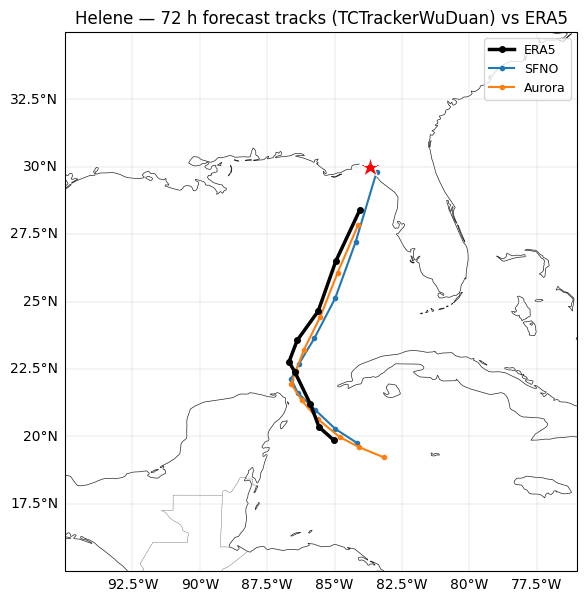

In [14]:
plot_tracks(era5_df, model_dfs, TRACK_DOMAIN, save_path=OUT_DIR / "track_map_72h.png")